In [7]:
import numpy as np
import pandas as pd
import zarr
import torch
import math
from datetime import datetime, timedelta
import statsmodels.api as sm
import os
import gc
from datetime import datetime, date, timedelta 
import re
import shutil
import xarray as xr
import matplotlib.pyplot as plt

'for i in range(100):\n    prova = ds["ndvi_processed"].isel(pixel=i).load()\n\n    plt.plot(np.arange(prova.shape[0]), prova.values)\n    plt.title(f"Pixel {i}")\n\n    # Save plot as image named after the pixel index\n    save_path = os.path.join(OUT_DIR, f"{i}.png")\n    plt.savefig(save_path, dpi=300)\n    plt.close()\n\nprint("Saved plots for the first 100 pixels.")'

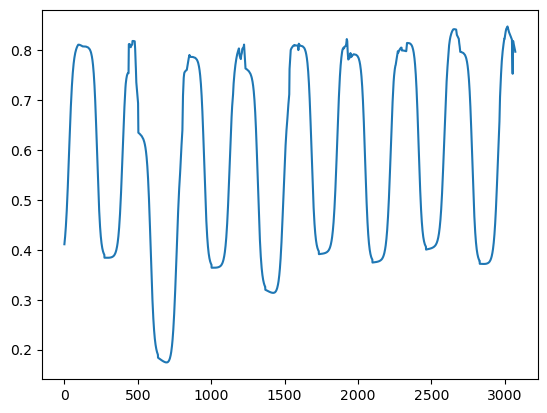

In [8]:
INPUT_DIR = "/home/francesco/data_scratch/swiss-ndvi-processing/ndvi_processed.zarr"
ds = xr.open_zarr(INPUT_DIR, chunks="auto")

prova = ds["ndvi_processed"].isel(pixel=slice(0, 1)).load()
plt.plot(np.arange(3073),prova[0].values)

OUT_DIR = "/home/francesco/data_scratch/swiss-ndvi-processing/workflow_implementation/figure/test_out_zarr"


"""for i in range(100):
    prova = ds["ndvi_processed"].isel(pixel=i).load()

    plt.plot(np.arange(prova.shape[0]), prova.values)
    plt.title(f"Pixel {i}")

    # Save plot as image named after the pixel index
    save_path = os.path.join(OUT_DIR, f"{i}.png")
    plt.savefig(save_path, dpi=300)
    plt.close()

print("Saved plots for the first 100 pixels.")"""


In [10]:
ds

<xarray.Dataset> Size: 12GB
Dimensions:         (pixel: 1000000, time: 3073)
Coordinates:
  * pixel           (pixel) float64 8MB nan 1.0 2.0 3.0 ... 1e+06 1e+06 1e+06
  * time            (time) float64 25kB 2.017e+07 2.017e+07 ... 2.025e+07
Data variables:
    ndvi_processed  (pixel, time) float32 12GB dask.array<chunksize=(5000, 3073), meta=np.ndarray>

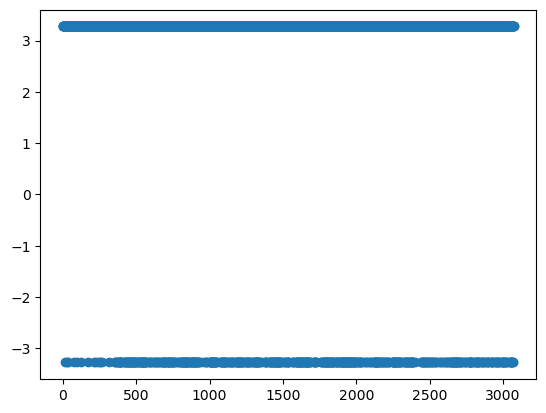

In [6]:
prova = ds["ndvi_processed"].isel(pixel=4777  ).load()
plt.scatter(np.arange(3073),prova.values)

In [35]:
for i in range(999999):
    prova = ds["ndvi_processed"].isel(pixel=i).load()

    # Check if any NDVI value > 1
    if np.any(prova.values > 1):
        print(f"Pixel {i} has NDVI values greater than 1")

Pixel 77 has NDVI values greater than 1
Pixel 533 has NDVI values greater than 1
Pixel 754 has NDVI values greater than 1
Pixel 938 has NDVI values greater than 1
Pixel 939 has NDVI values greater than 1
Pixel 941 has NDVI values greater than 1
Pixel 1051 has NDVI values greater than 1
Pixel 1052 has NDVI values greater than 1
Pixel 1053 has NDVI values greater than 1
Pixel 1054 has NDVI values greater than 1
Pixel 1442 has NDVI values greater than 1
Pixel 1446 has NDVI values greater than 1
Pixel 1574 has NDVI values greater than 1
Pixel 1575 has NDVI values greater than 1
Pixel 1576 has NDVI values greater than 1
Pixel 1577 has NDVI values greater than 1
Pixel 1578 has NDVI values greater than 1
Pixel 1922 has NDVI values greater than 1
Pixel 1938 has NDVI values greater than 1
Pixel 1950 has NDVI values greater than 1
Pixel 2088 has NDVI values greater than 1
Pixel 2089 has NDVI values greater than 1
Pixel 2090 has NDVI values greater than 1
Pixel 2432 has NDVI values greater than 1

KeyboardInterrupt: 

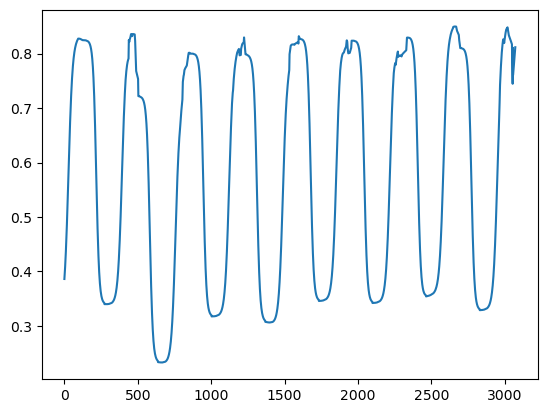

In [34]:
prova = ds["ndvi_processed"].isel(pixel=1).load()
plt.plot(np.arange(3073),prova.values)

In [33]:
((prova.values < 1) & (prova.values > 0)).sum()

np.int64(0)

In [30]:
prova[prova.values < 1]

<xarray.DataArray 'ndvi_processed' (time: 596)> Size: 2kB
array([-3.2768, -3.2768, -3.2768, -3.2768, -3.2768, -3.2768, -3.2768,
       -3.2768, -3.2768, -3.2768, -3.2768, -3.2768, -3.2768, -3.2768,
       -3.2768, -3.2768, -3.2768, -3.2768, -3.2768, -3.2768, -3.2768,
       -3.2768, -3.2768, -3.2768, -3.2768, -3.2768, -3.2768, -3.2768,
       -3.2768, -3.2768, -3.2768, -3.2768, -3.2768, -3.2768, -3.2768,
       -3.2768, -3.2768, -3.2768, -3.2768, -3.2768, -3.2768, -3.2768,
       -3.2768, -3.2768, -3.2768, -3.2768, -3.2768, -3.2768, -3.2768,
       -3.2768, -3.2768, -3.2768, -3.2768, -3.2768, -3.2768, -3.2768,
       -3.2768, -3.2768, -3.2768, -3.2768, -3.2768, -3.2768, -3.2768,
       -3.2768, -3.2768, -3.2768, -3.2768, -3.2768, -3.2768, -3.2768,
       -3.2768, -3.2768, -3.2768, -3.2768, -3.2768, -3.2768, -3.2768,
       -3.2768, -3.2768, -3.2768, -3.2768, -3.2768, -3.2768, -3.2768,
       -3.2768, -3.2768, -3.2768, -3.2768, -3.2768, -3.2768, -3.2768,
       -3.2768, -3.2768, -3.2768, -3.2768, -3.2768, -3.2768, -3.2768,
       -3.2768, -3.2768, -3.2768, -3.2768, -3.2768, -3.2768, -3.2768,
       -3.2768, -3.2768, -3.2768, -3.2768, -3.2768, -3.2768, -3.2768,
       -3.2768, -3.2768, -3.2768, -3.2768, -3.2768, -3.2768, -3.2768,
       -3.2768, -3.2768, -3.2768, -3.2768, -3.2768, -3.2768, -3.2768,
       -3.2768, -3.2768, -3.2768, -3.2768, -3.2768, -3.2768, -3.2768,
       -3.2768, -3.2768, -3.2768, -3.2768, -3.2768, -3.2768, -3.2768,
...
       -3.2768, -3.2768, -3.2768, -3.2768, -3.2768, -3.2768, -3.2768,
       -3.2768, -3.2768, -3.2768, -3.2768, -3.2768, -3.2768, -3.2768,
       -3.2768, -3.2768, -3.2768, -3.2768, -3.2768, -3.2768, -3.2768,
       -3.2768, -3.2768, -3.2768, -3.2768, -3.2768, -3.2768, -3.2768,
       -3.2768, -3.2768, -3.2768, -3.2768, -3.2768, -3.2768, -3.2768,
       -3.2768, -3.2768, -3.2768, -3.2768, -3.2768, -3.2768, -3.2768,
       -3.2768, -3.2768, -3.2768, -3.2768, -3.2768, -3.2768, -3.2768,
       -3.2768, -3.2768, -3.2768, -3.2768, -3.2768, -3.2768, -3.2768,
       -3.2768, -3.2768, -3.2768, -3.2768, -3.2768, -3.2768, -3.2768,
       -3.2768, -3.2768, -3.2768, -3.2768, -3.2768, -3.2768, -3.2768,
       -3.2768, -3.2768, -3.2768, -3.2768, -3.2768, -3.2768, -3.2768,
       -3.2768, -3.2768, -3.2768, -3.2768, -3.2768, -3.2768, -3.2768,
       -3.2768, -3.2768, -3.2768, -3.2768, -3.2768, -3.2768, -3.2768,
       -3.2768, -3.2768, -3.2768, -3.2768, -3.2768, -3.2768, -3.2768,
       -3.2768, -3.2768, -3.2768, -3.2768, -3.2768, -3.2768, -3.2768,
       -3.2768, -3.2768, -3.2768, -3.2768, -3.2768, -3.2768, -3.2768,
       -3.2768, -3.2768, -3.2768, -3.2768, -3.2768, -3.2768, -3.2768,
       -3.2768, -3.2768, -3.2768, -3.2768, -3.2768, -3.2768, -3.2768,
       -3.2768, -3.2768, -3.2768, -3.2768, -3.2768, -3.2768, -3.2768,
       -3.2768], dtype=float32)
Coordinates:
    pixel    float64 8B 4.203e+03
  * time     (time) float64 5kB 2.017e+07 2.017e+07 ... 2.025e+07 2.025e+07